# MidiSeq2PrefixInTokenLevel — SPLIT-MODALITY model validation

Loads the `Seq2CondSplitMidiPatchy` dataset and the `MidiSeq2PrefixInTokenLevel` /
`MidiSeq2PrefixInTokenLevelLoss` model — the **split-modality** midiseq2 variant that moves the
lilylet conditioning into the **token-level** decoder.

Unlike `MidiSeq2BgptSelfAttn` (one joint `[T,64]` tensor, lilylet ids left-aligned into the midi
frame, a frozen encoder scattered into the joint sequence), this pipeline keeps the two modalities
**separate**:

- `lyl_patches [B,Lmax,16]` (lilylet vocab 256) and `midi_patches [B,Mmax,64]` (midiseq2 vocab 838)
  — no widening, no shared integer axis, no clamp.
- The decoder runs **midi-only** self-attention under `midi_attn_mask` (the midi block of
  `build_vis`); there is **no lyl encoder**.
- For each supervised midi target patch, the lyl patches in its **cross window** — derived directly
  from measure ids (`midi_src` / `lyl_meas` / `w_cross`), **not a mask tensor** — are re-embedded raw
  and **prepended** in a `PrefixTokenLevelDecoder` at **negative, increasing** positions (`-Kmax..-1`).

This notebook: inspects a split batch, builds the model, verifies **(i)** it is a plain `nn.Module`
with no encoder, **(ii)** the midi-only mask gates the decoder, **(iii)** the measure-id cross gather
equals the `build_vis` cross selection, **(iv)** the token decoder's negative prefix positions and
`Kmax==0` parity with the stock `TokenLevelDecoder`, **(v)** the per-token-type metrics + nan-safe
`stat()`, runs a forward pass, and overfits one batch.

Config: `configs/midi-measurewise-seq2split-prefixtl.yaml` ·
Data: `~/data/lilylet/midi-measurewise/test20260629/cond-midiseq2-split.lmmw.pt`
(build it with `tools/midi/buildCondMidiseq2MeasurewiseSplit.py --dataset <test20260629>/dataset.yaml`).

In [1]:
from pathlib import Path
import sys

REPO_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'starry').is_dir())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import torch
from starry.utils.config import Configuration
from starry.utils.dataset_factory import loadDataset
from starry.utils.model_factory import loadModel

DATA_DIR = str(Path.home() / 'data')
CONFIG = str(REPO_ROOT / 'configs' / 'midi-measurewise-seq2split-prefixtl.yaml')
print('repo:', REPO_ROOT)
print('data dir:', DATA_DIR)

repo: /home/camus/work/deep-starry
data dir: /home/camus/data


## 1. Load dataset + a small CPU model, inspect one split batch

The corpus is NOT cropped (`max_patches: 0`), so we shrink the model (not the data) to keep this
validation quick on CPU. A 2-sample batch of differing length exercises padding. Note the two
independent patch widths on the batch: `lyl_patches` at 16, `midi_patches` at 64.

In [2]:
config = Configuration.createOrLoad(CONFIG, volatile=True)
config['data.batch_size'] = 2
config['trainer.device'] = 'cpu'
# smaller model keeps this validation quick on CPU (data stays uncropped).
config['model.args.d_model'] = 96
config['model.args.n_dec_layer'] = 2
config['model.args.token_num_layers'] = 2
config['model.args.n_head'] = 4
config['model.args.dec_num_key_value_heads'] = 4
config['model.args.num_key_value_heads'] = 4
config['model.args.d_inner'] = 192

train, val = loadDataset(config, data_dir=DATA_DIR, device='cpu')
print('train items:', len(train.dataset), 'val items:', len(val.dataset))

batch = next(iter(train))
print('batch keys:', list(batch.keys()))
for k in ['lyl_patches', 'lyl_masks', 'lyl_meas', 'midi_patches', 'midi_masks', 'midi_meas',
          'midi_src', 'midi_targets', 'midi_positions', 'midi_attn_mask']:
    print(f'  {k:16} {tuple(batch[k].shape)} {batch[k].dtype}')
print('lyl patch width  :', batch['lyl_patches'].shape[-1], '(lyl_patch_size=16)')
print('midi patch width :', batch['midi_patches'].shape[-1], '(midiseq2 patch_size=64)')
print('max lyl id       :', int(batch['lyl_patches'].max()), '(< lyl vocab 256)')
print('max midi id      :', int(batch['midi_patches'].max()), '(midiseq2 vocab up to 837)')
print('real lyl / midi  :', batch['lyl_masks'].sum(1).tolist(), '/', batch['midi_masks'].sum(1).tolist())
print('midi targets     :', batch['midi_targets'].sum(1).tolist())
# split layout keeps the two vocabularies disjoint: lyl ids never reach the midi range.
assert int(batch['lyl_patches'].max()) < 256

train items: 205 val items: 10
batch keys: ['lyl_patches', 'lyl_masks', 'lyl_meas', 'midi_patches', 'midi_masks', 'midi_meas', 'midi_src', 'midi_targets', 'midi_positions', 'midi_attn_mask', 'lyl_patch_size', 'midi_patch_size']
  lyl_patches      (2, 521, 16) torch.int64
  lyl_masks        (2, 521) torch.int64
  lyl_meas         (2, 521) torch.int64
  midi_patches     (2, 190, 64) torch.int64
  midi_masks       (2, 190) torch.int64
  midi_meas        (2, 190) torch.int64
  midi_src         (2, 190) torch.int64
  midi_targets     (2, 190) torch.int64
  midi_positions   (2, 190) torch.int64
  midi_attn_mask   (2, 1, 190, 190) torch.bool
lyl patch width  : 16 (lyl_patch_size=16)
midi patch width : 64 (midiseq2 patch_size=64)
max lyl id       : 248 (< lyl vocab 256)
max midi id      : 836 (midiseq2 vocab up to 837)
real lyl / midi  : [344, 521] / [136, 190]
midi targets     : [135, 189]


## 2. Build the model via the factory — a plain `nn.Module`, no encoder

`MidiSeq2PrefixInTokenLevel` is a plain `nn.Module` (it does **not** subclass `MidiSeq2BgptSelfAttn`):
it builds only what it uses — `midi_embedding`, a midi self-attention `decoder` (`LlamaModel`), a
`PrefixTokenLevelDecoder` token head, and the raw-lyl `lyl_prefix_embedding`. There is no
`lyl_encoder` / `enc_proj`.

In [3]:
deducer = loadModel(config['model'], imports=config['imports'])
model = loadModel(config['model'], postfix='Loss', imports=config['imports'])
print('deducer:', type(deducer).__name__, '| loss model:', type(model).__name__)
print('deducer MRO:', [c.__name__ for c in type(deducer).__mro__[:3]])

d = model.deducer
print('child modules:', [n for n, _ in d.named_children()])
print('has lyl_encoder:', hasattr(d, 'lyl_encoder'), '| has enc_proj:', hasattr(d, 'enc_proj'))
n_params = sum(p.numel() for p in d.parameters())
print('params: %.2fM' % (n_params / 2**20))
print('midi_embedding in_features   :', d.midi_embedding.in_features, '(64*838=53632)')
print('lyl_prefix_embedding in_feat :', d.lyl_prefix_embedding.in_features, '(16*256=4096)')
print('decoder layers:', d.decoder.config.num_hidden_layers,
      '| token head:', type(d.token_level_decoder).__name__,
      'layers', d.token_level_decoder.base.config.num_hidden_layers,
      'vocab', d.token_level_decoder.base.config.vocab_size)
print('w_cross:', d.w_cross, '| patch_size:', d.patch_size, '| lyl_patch_size:', d.lyl_patch_size)
assert not hasattr(d, 'lyl_encoder') and not hasattr(d, 'enc_proj')
assert d.token_level_decoder.base.config.vocab_size == 838

deducer: MidiSeq2PrefixInTokenLevel | loss model: MidiSeq2PrefixInTokenLevelLoss
deducer MRO: ['MidiSeq2PrefixInTokenLevel', 'Module', 'object']
child modules: ['midi_embedding', 'lyl_prefix_embedding', 'decoder', 'token_level_decoder']
has lyl_encoder: False | has enc_proj: False
params: 5.79M
midi_embedding in_features   : 53632 (64*838=53632)
lyl_prefix_embedding in_feat : 4096 (16*256=4096)
decoder layers: 2 | token head: PrefixTokenLevelDecoder layers 2 vocab 838
w_cross: 1 | patch_size: 64 | lyl_patch_size: 16


## 3. Midi-only mask gates the decoder

Blocking a real midi query row in `midi_attn_mask` changes that row's decoder hidden state, while an
unaffected earlier row is bit-identical — the windowed midi->midi coupling is enforced by the fused
attention backbone. (There is no lyl in the decoder at all — the lilylet signal only enters later, at
the token level.)

In [4]:
m = model.deducer
m.eval()
midi_patches = batch['midi_patches'].reshape(len(batch['midi_patches']), -1, m.patch_size)
b = int(batch['midi_masks'].sum(1).argmax())        # densest midi sample
with torch.no_grad():
    embeds = m._midi_embed(midi_patches)
real_midi = (batch['midi_masks'][b] == 1).nonzero().flatten()
qrow = int(real_midi[-1]); row0 = int(real_midi[0])
full = batch['midi_attn_mask'].clone()
blocked = full.clone()
blocked[b, 0, qrow, :] = False
blocked[b, 0, qrow, qrow] = True
with torch.no_grad():
    h_full = m.decoder(inputs_embeds=embeds, attention_mask=full, position_ids=batch['midi_positions'])['last_hidden_state']
    h_blk = m.decoder(inputs_embeds=embeds, attention_mask=blocked, position_ids=batch['midi_positions'])['last_hidden_state']
print('blocked query row hidden changes  :', not torch.allclose(h_full[b, qrow], h_blk[b, qrow], atol=1e-6))
print('earlier row (unaffected) identical:', torch.allclose(h_full[b, row0], h_blk[b, row0], atol=1e-6))
assert not torch.allclose(h_full[b, qrow], h_blk[b, qrow], atol=1e-6)
assert torch.allclose(h_full[b, row0], h_blk[b, row0], atol=1e-6)

blocked query row hidden changes  : True
earlier row (unaffected) identical: True


## 4. Measure-id cross gather == `build_vis` cross selection

The distinctive design point: instead of consuming a midi->lyl cross **mask**, the model computes,
per midi target patch, which lyl patches fall in its `w_cross` window directly from measure ids
(`_gather_lyl_prefix`). This must select exactly the same lyl set as the reference `build_vis` cross
block. We verify equality for `w_cross` in `{1, 2, 4}` on every midi target of the batch.

In [5]:
from starry.midi.data.condPatchy import build_vis

def build_vis_cross_sets(batch, b, wc):
    '''Reference lyl selection per midi target, from build_vis on the reconstructed joint sequence.'''
    Lp = int(batch['lyl_masks'][b].sum()); Mp = int(batch['midi_masks'][b].sum())
    mod = torch.cat((torch.zeros(Lp, dtype=torch.long), torch.ones(Mp, dtype=torch.long)))
    own = torch.cat((batch['lyl_meas'][b, :Lp], batch['midi_meas'][b, :Mp]))
    src = torch.cat((batch['lyl_meas'][b, :Lp], batch['midi_src'][b, :Mp]))
    vis = build_vis(mod, own, src, 4, wc)                       # w_midi irrelevant to the cross block
    return {q: set(torch.nonzero((vis[Lp + q, :Lp]) & (mod[:Lp] == 0)).flatten().tolist()) for q in range(Mp)}

def model_cross_sets(batch, b, wc):
    '''The model's measure-id rule (mirrors _gather_lyl_prefix).'''
    Lp = int(batch['lyl_masks'][b].sum()); Mp = int(batch['midi_masks'][b].sum())
    lyl_meas = batch['lyl_meas'][b, :Lp]; midi_src = batch['midi_src'][b, :Mp]
    out = {}
    for p in range(Mp):
        s = int(midi_src[p])
        header = lyl_meas == 0
        inwin = (s != 0) & (lyl_meas > s - wc) & (lyl_meas <= s)
        out[p] = set(torch.nonzero(header | inwin).flatten().tolist())
    return out

for wc in (1, 2, 4):
    for bb in range(batch['midi_masks'].shape[0]):
        ref = build_vis_cross_sets(batch, bb, wc)
        got = model_cross_sets(batch, bb, wc)
        assert ref == got, (bb, wc, 'cross-set mismatch')
print('measure-id cross gather == build_vis cross selection for w_cross in {1,2,4}  OK')

measure-id cross gather == build_vis cross selection for w_cross in {1,2,4}  OK


## 5. Token decoder: negative prefix positions + `Kmax==0` parity

The `PrefixTokenLevelDecoder` prepends `Kmax` lyl prefixes at positions `-Kmax..-1`, the encoded
patch at `0`, and the `P` teacher-forced tokens at `1..P`; the prefix slots are excluded from the
returned logits (so downstream sees `[N, P+1, vocab]`). With `Kmax==0` it reduces **exactly** to the
stock `TokenLevelDecoder`.

In [6]:
from starry.bgpt.decoders import TokenLevelDecoder

# (a) run the real gather and confirm negative-increasing positions + prefix coverage
m.eval()
mp = batch['midi_patches'].reshape(len(batch['midi_patches']), -1, m.patch_size)
tgt_idx = torch.nonzero(batch['midi_targets'] == 1, as_tuple=False)
pe, pm = m._gather_lyl_prefix(batch['lyl_patches'], batch['lyl_masks'], batch['lyl_meas'],
                             batch['midi_src'], tgt_idx)
Kmax = pe.shape[1]
P1 = m.patch_size + 1
pos = torch.cat((torch.arange(-Kmax, 0), torch.arange(0, P1))).tolist()
print('Kmax:', Kmax, '| positions head/tail:', pos[:3], '...', pos[-3:])
print('prefix_mask rowsums: min', int(pm.sum(1).min()), 'max', int(pm.sum(1).max()), '(>=1 per body target)')
assert pos[:Kmax] == list(range(-Kmax, 0)) and pos[Kmax] == 0
assert int(pm.sum(1).min()) >= 1

# (b) Kmax==0 parity: PrefixTokenLevelDecoder with no prefix == stock TokenLevelDecoder
ptl = m.token_level_decoder
N, P, dm = 3, m.patch_size, m.d_model
enc = torch.randn(N, dm); tgt = torch.randint(1, m.midi_vocab_size, (N, P))
with torch.no_grad():
    out_no_prefix = ptl(enc, tgt, None, None)
    out_stock = super(type(ptl), ptl).forward(enc, tgt)     # grandparent TokenLevelDecoder.forward
dloss = abs(float(out_no_prefix.loss) - float(out_stock.loss))
print('Kmax==0 loss diff vs stock TokenLevelDecoder:', dloss)
assert dloss < 1e-5 and out_no_prefix.logits.shape == out_stock.logits.shape

Kmax: 12 | positions head/tail: [-12, -11, -10] ... [62, 63, 64]
prefix_mask rowsums: min 7 max 12 (>=1 per body target)


Kmax==0 loss diff vs stock TokenLevelDecoder: 0.0


## 6. Forward pass: loss, per-token-type metrics, inspectRun

The Loss reuses `MidiSeq2BgptSelfAttnLoss`'s machinery: base `acc`/`err` (always) plus, in **eval**
mode, the per-midiseq2-token-type ERROR rates (`err_type` / `err_elapse` / `err_pitch` / `err_vel` /
`err_channel` / `err_nibble`), each a nan-safe `WeightedValue(err, count)`. The token output exposes
prefix-sliced logits `[N, patch_size+1, vocab]`, so every helper works unchanged.

In [7]:
from starry.utils.weightedValue import WeightedValue

model.train()
loss, metric_train = model(batch)
print('TRAIN loss:', loss.item(), '| metric keys:', sorted(metric_train.keys()))
assert loss.requires_grad and loss.dim() == 0 and torch.isfinite(loss)
assert not any(isinstance(v, WeightedValue) for v in metric_train.values()), 'grouped metrics must be train-gated'

model.eval()
loss_e, metric_eval = model(batch)
print('\nEVAL loss:', loss_e.item())
plain = {k: v for k, v in metric_eval.items() if not isinstance(v, WeightedValue)}
grouped = {k: v for k, v in metric_eval.items() if isinstance(v, WeightedValue)}
print('plain metrics:', {k: round(v, 4) for k, v in plain.items()})
print('per-token-type error (rate | count):')
for k in sorted(grouped):
    wv = grouped[k]
    print('  %-12s %s  (n=%d)' % (k, ('  --  ' if wv.weight == 0 else '%.4f' % wv.value), wv.weight))
    assert wv.weight == 0 or 0.0 <= wv.value <= 1.0

with torch.no_grad():
    insp = model.inspectRun(batch)
print('\ninspect logits:', tuple(insp['logits'].shape), '| n_patches:', insp['n_patches'])
assert insp['n_patches'] == sum(batch['midi_targets'].sum(dim=1).tolist())
assert insp['logits'].shape[1] == d.patch_size + 1 and insp['logits'].shape[2] == 838

TRAIN loss: 6.659619331359863 | metric keys: ['acc', 'err']



EVAL loss: 6.659613132476807
plain metrics: {'acc': 0.0028, 'err': 0.9972}
per-token-type error (rate | count):
  err_channel    --    (n=0)
  err_elapse   0.9882  (n=3305)
  err_nibble   1.0000  (n=50)
  err_pitch    0.9986  (n=5022)
  err_type     1.0000  (n=5038)
  err_vel      0.9997  (n=3354)



inspect logits: (324, 65, 838) | n_patches: 324


## 7. Overfit one batch — loss should drop, acc should rise

In [8]:
model.train()
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
history = []
for step in range(20):
    opt.zero_grad()
    loss, metric = model(batch)
    loss.backward()
    opt.step()
    history.append((loss.item(), metric['acc']))
    if step % 5 == 0 or step == 19:
        print(f'step {step:02d}  loss={loss.item():.4f}  acc={metric["acc"]:.4f}')

# grads flow to the raw-lyl prefix embedding (the only path lilylet influences the loss).
g = model.deducer.lyl_prefix_embedding.weight.grad
print('\nlyl_prefix_embedding grad finite:', g is not None and bool(torch.isfinite(g).all()))
print('loss start -> end:', round(history[0][0], 4), '->', round(history[-1][0], 4))
print('acc  start -> end:', round(history[0][1], 4), '->', round(history[-1][1], 4))
assert history[-1][0] < history[0][0], 'loss did not decrease'

step 00  loss=6.6596  acc=0.0028


step 05  loss=5.5224  acc=0.4486


step 10  loss=4.7327  acc=0.5760


step 15  loss=4.0877  acc=0.5929


step 19  loss=3.6504  acc=0.5991

lyl_prefix_embedding grad finite: True
loss start -> end: 6.6596 -> 3.6504
acc  start -> end: 0.0028 -> 0.5991


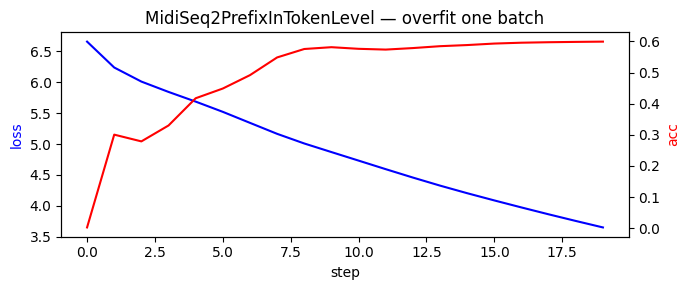

In [9]:
%matplotlib inline
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline', force=True)
import matplotlib.pyplot as plt

losses = [h[0] for h in history]
accs = [h[1] for h in history]
fig, ax1 = plt.subplots(figsize=(7, 3))
ax1.plot(losses, 'b-', label='loss'); ax1.set_ylabel('loss', color='b'); ax1.set_xlabel('step')
ax2 = ax1.twinx(); ax2.plot(accs, 'r-', label='acc'); ax2.set_ylabel('acc', color='r')
plt.title('MidiSeq2PrefixInTokenLevel — overfit one batch'); plt.tight_layout(); plt.show()